<p><font size="6" color='grey'> <b>
KI-Agenten. Verstehen. Anwenden. Gestalten.
</b></font> </br></p>



<p><font size="5" color='grey'> <b>
StateGraph Basics
</b></font> </br></p>

---

In [47]:
#@title 🛠️ Umgebung einrichten{ display-mode: "form" }
!uv pip install --system -q git+https://github.com/ralf-42/Agenten.git#subdirectory=04_modul

# LangSmith Env-Vars VOR allen LangChain-Imports setzen
import os
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"]    = "M09-StateGraph-Basics"
os.environ["LANGSMITH_ENDPOINT"]   = "https://eu.api.smith.langchain.com"

from genai_lib.utilities import (
    check_environment,
    get_ipinfo,
    setup_api_keys,
    mprint,
    install_packages,
    mermaid,
    get_model_profile,
    extract_thinking,
    load_prompt,
    show_trace
)

setup_api_keys(['OPENAI_API_KEY', 'LANGSMITH_API_KEY'], create_globals=False)
print()
check_environment()
print()
get_ipinfo()

# Modell-Konfiguration — Rollen als Konstanten
from genai_lib.model_config import BASELINE, ROUTER, JUDGE, PLANNER, WORKER, WORKER_PREMIUM, CODING, EMBEDDINGS
# LangSmith Tracing
run_cfg = {
    "run_name": "M09_StateGraph_Basics",
    "tags": ["m09", "stategraph"],
    "metadata": {"notebook": "M09", "version": "1.0"}
}


✓ OPENAI_API_KEY erfolgreich gesetzt
✓ LANGSMITH_API_KEY erfolgreich gesetzt

Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

Installierte LangChain- und LangGraph-Bibliotheken:
langchain                                1.2.15
langchain-chroma                         1.1.0
langchain-classic                        1.0.4
langchain-community                      0.4.1
langchain-core                           1.3.1
langchain-ollama                         1.1.0
langchain-openai                         1.2.0
langchain-text-splitters                 1.1.2
langgraph                                1.1.9
langgraph-checkpoint                     4.0.2
langgraph-prebuilt                       1.0.10
langgraph-sdk                            0.3.13

IP-Adresse: 34.26.107.195
Hostname: 195.107.26.34.bc.googleusercontent.com
Stadt: North Charleston
Region: South Carolina
Land: US
Koordinaten: 32.8546,-79.9748
Provider: AS396982 Google LLC
Postleitzahl: 29415
Zeitzone: America/New_Y

**Was passiert hier?**

1. `StateGraph(...)` — definiert den Graphen mit dem State-Schema

# 1 | Übersicht
---



*Warum LangGraph?* hat gezeigt, **warum** LangGraph existiert und einen ersten 1-Node-Graphen gebaut.  
Dieses Modul geht tiefer: Wir bauen einen **vollständigen 2-Node-Graphen** mit mehreren State-Feldern,  
verschiedenen Edge-Typen und vollständiger Visualisierung.



**Was behandelt dieses Modul**

| Thema | Inhalt |
|-------|--------|
| **State-Design** | TypedDict mit mehreren Feldern, Reducer vs. Überschreiben |
| **Node-Regeln** | Signatur, partieller Return, Fehlerbehandlung |
| **Edges** | `add_edge()`, kurze Vorschau auf `add_conditional_edges()` |
| **Kompilierung** | `compile()`, `recursion_limit`, Graph-Visualisierung |
| **Ausführung** | `invoke()`, `stream()`, State nach Ausführung inspizieren |
| **LangSmith** | Trace mit `run_name`, Node-by-Node-Sicht |


In [48]:
#@markdown   <p><font size="4" color='green'>  StateGraph</font> </br></p>



diagram = '''
%%{init: {'theme':'forest'}}%%
flowchart LR
    STATE[/"📦 State\n(zentrale Wahrheit)"/]
    NODE_A["Node A\nliest State\nschreibt State"] --> STATE
    STATE --> NODE_B["Node B\nliest State\nschreibt State"]
    STATE --> EDGE{"Edge /\nRouter"}
    EDGE -->|"Pfad 1"| NODE_A
    EDGE -->|"Pfad 2"| NODE_B

    style STATE fill:#FF9800,color:#fff
    style EDGE  fill:#F44336,color:#fff
    style NODE_A fill:#4CAF50,color:#fff
    style NODE_B fill:#2196F3,color:#fff
'''
mermaid(diagram, width=800)


**Das Praxisbeispiel: Qualitäts-Agent**

Es wird ein **zweistufiger Analyse-Agent** gebaut:

- **Node 1 `entwurf_node`**: Erstellt einen ersten Textentwurf
- **Node 2 `korrektorat_node`**: Verbessert den Entwurf

Jeder Node liest aus dem **gemeinsamen State** und schreibt seine Ergebnisse zurück.

In [ ]:
from langchain.chat_models import init_chat_model
from genai_lib.model_config import JUDGE
llm = init_chat_model(JUDGE)


In [50]:
#@markdown   <p><font size="4" color='green'>  flowchart</font> </br></p>

diagram = '''
%%{init: {'theme':'forest'}}%%
flowchart LR
    ST([START])
    N1["<b>Node 1</b>\nentwurf_node()\n▸ liest: anfrage\n▸ schreibt: entwurf"]
    N2["<b>Node 2</b>\nkorrektorat_node()\n▸ liest: entwurf\n▸ schreibt: finale_antwort"]
    FIN([FINISH])
    S[/"<b>State</b>\nanfrage: str\nentwurf: str\nfinale_antwort: str\nschritt: int"/]

    ST --> N1 --> N2 --> FIN
    N1 <-.->|"lesen / schreiben"| S
    N2 <-.->|"lesen / schreiben"| S

    style ST fill:#90EE90
    style FIN fill:#FFB6C1
    style S fill:#E8E8FF,stroke:#9999CC
'''

mermaid(diagram, width=900)

# 2 | StateGraph erstellen
---



**Der State: Einzige Wahrheitsquelle**

Der **State** ist das Herzstück jedes LangGraph-Workflows.  
Alle Nodes lesen daraus und schreiben dorthin – sie kommunizieren **nie direkt**.



**TypedDict: Schnell, typsicher, empfohlen**

| Kriterium | TypedDict | Pydantic BaseModel |
|-----------|----------|--------------------|
| **Empfehlung** | ✅ Für Graph-State | ⚠️ Nur für API-Grenzen |
| **Performance** | Kein Overhead | Langsamer (Validation) |
| **Typen** | Statische Hints | Strikte Laufzeit-Validation |



**Reducer: Wie der State aktualisiert wird**

LangGraph unterscheidet zwei Verhaltensweisen bei State-Updates:

| Typ | Verhalten | Beispiel |
|-----|-----------|----------|
| **Überschreiben** (Standard) | Neuer Wert ersetzt alten | `schritt: 2` → `schritt: 3` |
| **Reducer** (`add_messages`) | Neue Werte werden **angehängt** | `[msg1]` + `[msg2]` → `[msg1, msg2]` |

> **Wichtig:** Für `messages` immer `Annotated[list, add_messages]` verwenden –  
> sonst wird der Gesprächsverlauf bei jedem Node-Return überschrieben!

In [51]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages

# ─── State-Definition ────────────────────────────────────────────────────
class QualitätsState(TypedDict):
    """State des Qualitäts-Agenten.

    Alle Felder werden von den Nodes geteilt.
    Jeder Node liest und schreibt nur die Felder, die er benötigt.
    """
    messages:      Annotated[list, add_messages]  # Reducer: immer anhaengen
    anfrage:       str   # Eingabe des Nutzers (unveraendert)
    entwurf:       str   # Node 1 schreibt hier
    finale_antwort: str  # Node 2 schreibt hier
    schritt:       int   # Zaehlt Ausführungsschritte

# ─── Initialer State ─────────────────────────────────────────────────────
start_state: QualitätsState = {
    "messages":       [],
    "anfrage":        "",    # Wird beim Aufruf gesetzt
    "entwurf":        "",
    "finale_antwort": "",
    "schritt":        0,
}
print("State-Schema:")
for feld, wert in start_state.items():
    print(f"  {feld:18s}: {type(wert).__name__}")

State-Schema:
  messages          : list
  anfrage           : str
  entwurf           : str
  finale_antwort    : str
  schritt           : int


In [52]:
from langgraph.graph import StateGraph, START, END

# StateGraph mit dem State-Schema initialisieren
builder = StateGraph(QualitätsState)

print("StateGraph erstellt")
print("Nächste Schritte: Nodes hinzufügen, Edges verbinden, kompilieren")


StateGraph erstellt
Nächste Schritte: Nodes hinzufügen, Edges verbinden, kompilieren


# 3 | Nodes definieren
---


**Die 4 Regeln für Node-Funktionen**

Eine Node-Funktion empfängt immer den vollständigen State und gibt ausschließlich ein `dict` zurück — also `def node(state: State) -> dict:`. Dabei müssen nur die veränderten Felder zurückgegeben werden; LangGraph merged automatisch mit dem bestehenden State, sodass unveränderte Felder erhalten bleiben. Treten Fehler auf, werden diese nicht mit `raise` weitergeleitet, sondern als String in ein Fehlerfeld des States geschrieben — das hält den Graphen stabil. Schließlich gilt: Nodes sind pure Funktionen ohne globale Seiteneffekte; der State ist die einzige Kommunikationsebene zwischen Nodes.



**Partieller Return – warum kein vollständiger State?**

LangGraph **merged** automatisch:

```python
# Aktueller State:
# { anfrage: "Hallo", entwurf: "", schritt: 0 }

# Node gibt zurück:
return {"entwurf": "Erster Entwurf...", "schritt": 1}

# Neuer State nach Merge:
# { anfrage: "Hallo", entwurf: "Erster Entwurf...", schritt: 1 }
```

> `anfrage` bleibt erhalten, obwohl der Node es nicht zurückgegeben hat!

In [53]:
from langchain_core.messages import HumanMessage, AIMessage

entwurf_prompt     = load_prompt("https://github.com/ralf-42/Agenten/blob/main/05_prompt/m09_entwurf_prompt.md", mode="T")
korrektorat_prompt = load_prompt("https://github.com/ralf-42/Agenten/blob/main/05_prompt/m09_korrektorat_prompt.md", mode="T")

# ─── Node 1: Entwurf erstellen ───────────────────────────────────────────
def entwurf_node(state: QualitätsState) -> dict:
    """Erstellt einen ersten Textentwurf."""
    prompt_value = entwurf_prompt.invoke({"anfrage": state["anfrage"]}, config=run_cfg)
    response = llm.invoke(prompt_value, config=run_cfg)
    return {"entwurf": response.content}

# ─── Node 2: Korrektorat ─────────────────────────────────────────────────
def korrektorat_node(state: QualitätsState) -> dict:
    """Verbessert Sprache und Struktur des Entwurfs."""
    prompt_value = korrektorat_prompt.invoke({"entwurf": state["entwurf"]}, config=run_cfg)
    response = llm.invoke(prompt_value, config=run_cfg)
    return {"entwurf": response.content}


In [54]:
# ─── Node 2: Korrektorat durchführen ────────────────────────────────────
def korrektorat_node(state: QualitätsState) -> dict:
    """Verbessert den Entwurf aus Node 1.

    Liest: state["entwurf"]
    Schreibt: finale_antwort, schritt, messages
    """
    print(f"  [Node 2] Verbessere Entwurf ({len(state['entwurf'])} Zeichen)")

    prompt_value = korrektorat_prompt.invoke({"entwurf": state["entwurf"]}, config=run_cfg)
    response = llm.invoke(prompt_value.messages, config=run_cfg)

    return {
        "messages": [*prompt_value.messages, response],
        "finale_antwort": response.content,
        "schritt": state["schritt"] + 1,
    }

In [55]:
#@markdown   <p><font size="4" color='green'>  flowchart</font> </br></p>

diagram = '''
%%{init: {'theme':'forest'}}%%
flowchart TB
    subgraph Node1["entwurf_node() – Node 1"]
        N1R["Liest: anfrage"] --> N1L["LLM: Erstellt Entwurf"]
        N1L --> N1W["Schreibt: entwurf, schritt"]
    end

    subgraph State["Gemeinsamer State"]
        direction LR
        F1["anfrage: str"]
        F2["entwurf: str"]
        F3["finale_antwort: str"]
        F4["schritt: int"]
        F5["messages: list"]
    end

    subgraph Node2["korrektorat_node() – Node 2"]
        N2R["Liest: entwurf"] --> N2L["LLM: Verbessert Text"]
        N2L --> N2W["Schreibt: finale_antwort, schritt"]
    end

    Node1 <-->|merge| State
    Node2 <-->|merge| State

    style State fill:#E8E8FF,stroke:#9999CC
    style Node1 fill:#E8FFE8
    style Node2 fill:#FFE8E8
'''

mermaid(diagram, width=1050)

# 4 | Edges verbinden
---



**Edge-Typen**

| Typ | Methode | Wann verwenden |
|-----|---------|----------------|
| **Einfache Edge** | `add_edge(from, to)` | Immer dieser Weg |
| **Conditional Edge** | `add_conditional_edges(from, fn)` | Entscheidung zur Laufzeit |

**START und END**

```python
from langgraph.graph import START, END

# START = spezieller Eingangsknoten (kein Node, kein Code)
# END   = spezieller Ausgangsknoten (Workflow beenden)
builder.add_edge(START, "mein_node")   # Einstieg
builder.add_edge("mein_node", END)     # Ausstieg
```

**Conditional Edges – kurze Vorschau (Details folgen im nächsten Modul)**

```python
# Routing-Funktion: gibt den Namen des nächsten Nodes zurück
def routing_fn(state: State) -> str:
    if state["Qualität"] == "schlecht":
        return "nochmal_verbessern"   # Schleife
    return END                         # Fertig

builder.add_conditional_edges(
    "korrektorat",    # Von diesem Node
    routing_fn,       # Diese Funktion entscheidet
)
```

> *Conditional Routing & Tool-Loop* zeigt Conditional Edges und Tool-Loops im Detail.

In [56]:
# Nodes zum Builder hinzufügen
builder.add_node("entwurf",    entwurf_node)
builder.add_node("korrektorat", korrektorat_node)

# Edges verbinden: START → entwurf → korrektorat → END
builder.add_edge(START,         "entwurf")
builder.add_edge("entwurf",     "korrektorat")
builder.add_edge("korrektorat", END)

print("Nodes registriert:", list(builder.nodes.keys()))
print("Graph-Struktur:")
print("  START → entwurf → korrektorat → END")

Nodes registriert: ['entwurf', 'korrektorat']
Graph-Struktur:
  START → entwurf → korrektorat → END


# 5 | Graph kompilieren & testen
---



**Kompilierung: Builder → unveränderlicher Graph**

Nach `compile()` kann der Graph **nicht mehr verändert** werden.  
Die Kompilierung prüft den Graphen auf Vollständigkeit und erzeugt den ausführbaren Workflow.

| Option | Beschreibung | Standard |
|--------|-------------|----------|
| `checkpointer=` | Persistenz (MemorySaver/PostgresSaver) | Kein Checkpointing |
| `interrupt_before=` | Nodes bei denen pausiert wird | `[]` |
| `interrupt_after=` | Nodes nach denen pausiert wird | `[]` |

> **Best Practice:** Immer `draw_mermaid_png()` nach `compile()` aufrufen –  
> zeigt den **tatsächlich** kompilierten Graphen.

In [57]:
# Graph kompilieren
graph = builder.compile()

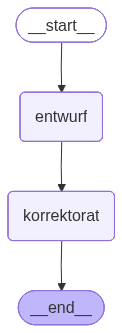

In [58]:
# Graph visualisieren
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [59]:
# Graph ausführen mit invoke()
initial_state: QualitätsState = {
    "messages":       [],
    "anfrage":        "Die Bedeutung von RAG-Systemen in modernen KI-Anwendungen",
    "entwurf":        "",
    "finale_antwort": "",
    "schritt":        0,
}

print("Starte Graphen...\n")
ergebnis = graph.invoke(initial_state, config=run_cfg)

mprint(f"""
## Ergebnis nach invoke()

**Schritte ausgeführt:** {ergebnis["schritt"]}

**Entwurf (Node 1):**
{ergebnis["entwurf"]}

---

**Finale Antwort (Node 2):**
{ergebnis["finale_antwort"]}

**Nachrichten im State:** {len(ergebnis["messages"])} Einträge
""")

Starte Graphen...

  [Node 2] Verbessere Entwurf (548 Zeichen)



## Ergebnis nach invoke()

**Schritte ausgeführt:** 1

**Entwurf (Node 1):**
RAG-Systeme (Retrieval-Augmented Generation) spielen eine entscheidende Rolle in modernen KI-Anwendungen, indem sie die Stärken von Informationsabruf und Textgenerierung kombinieren. Sie ermöglichen es KI-Modellen, auf umfangreiche Wissensdatenbanken zuzugreifen und präzise, kontextbezogene Antworten zu liefern. Dadurch verbessern sie die Relevanz und Genauigkeit der generierten Inhalte erheblich. In einer Welt, die von Datenüberflutung geprägt ist, bieten RAG-Systeme eine effiziente Lösung für qualitativ hochwertige Informationsverarbeitung.

---

**Finale Antwort (Node 2):**
RAG-Systeme (Retrieval-Augmented Generation) sind entscheidend für moderne KI-Anwendungen, da sie die Vorteile von Informationsabruf und Textgenerierung vereinen. Diese Systeme ermöglichen es KI-Modellen, auf umfangreiche Wissensdatenbanken zuzugreifen und präzise, kontextbezogene Antworten zu liefern. Dadurch steigern sie die Relevanz und Genauigkeit der generierten Inhalte erheblich. In einer Welt, die von Datenüberflutung geprägt ist, stellen RAG-Systeme eine effiziente Lösung für die qualitativ hochwertige Verarbeitung von Informationen dar.

**Nachrichten im State:** 3 Einträge


In [60]:
# State nach Ausführung inspizieren
print("=== State-Inspektion ===")
for feld, wert in ergebnis.items():
    if feld == "messages":
        print(f"  messages: {len(wert)} Einträge")
        for i, msg in enumerate(wert):
            typ = type(msg).__name__
            inhalt = msg.content[:60].replace("\n", " ") + "..."
            print(f"    [{i}] {typ}: {inhalt}")
    elif isinstance(wert, str) and len(wert) > 60:
        print(f"  {feld}: {wert[:60]}...")
    else:
        print(f"  {feld}: {repr(wert)}")

=== State-Inspektion ===
  messages: 3 Einträge
    [0] SystemMessage: Du bist Lektor fuer klare, praezise Fachtexte. Verbessere Sp...
    [1] HumanMessage: Verbessere den folgenden Text sprachlich und inhaltlich. Mac...
    [2] AIMessage: RAG-Systeme (Retrieval-Augmented Generation) sind entscheide...
  anfrage: 'Die Bedeutung von RAG-Systemen in modernen KI-Anwendungen'
  entwurf: RAG-Systeme (Retrieval-Augmented Generation) spielen eine en...
  finale_antwort: RAG-Systeme (Retrieval-Augmented Generation) sind entscheide...
  schritt: 1


In [61]:
# Graph mit stream() Schritt für Schritt verfolgen
print("=== stream() - Node-by-Node ===\n")

stream_state: QualitätsState = {
    **initial_state,
    "anfrage": "Warum ist Checkpointing in LangGraph wichtig?",
}

for schritt, event in enumerate(graph.stream(stream_state, stream_mode="updates")):
    node_name = list(event.keys())[0]
    node_output = event[node_name]

    print(f"--- Schritt {schritt + 1}: Node '{node_name}' ---")
    for feld, wert in node_output.items():
        if feld == "messages":
            print(f"  messages: +{len(wert)} neue Einträge")
        elif isinstance(wert, str) and len(wert) > 80:
            print(f"  {feld}: {wert[:80]}...")
        else:
            print(f"  {feld}: {repr(wert)}")
    print()


=== stream() - Node-by-Node ===

--- Schritt 1: Node 'entwurf' ---
  entwurf: Checkpointing in LangGraph ist entscheidend, um den Fortschritt von LangChain-Pr...

  [Node 2] Verbessere Entwurf (462 Zeichen)
--- Schritt 2: Node 'korrektorat' ---
  messages: +3 neue Einträge
  finale_antwort: Checkpointing in LangGraph spielt eine entscheidende Rolle bei der Sicherung des...
  schritt: 1



# 6 | Graph im LangSmith
---



LangGraph-Traces in LangSmith zeigen eine **Node-by-Node-Sicht** des Workflows –
ideal zum Verstehen und Debuggen.

**Was LangSmith für StateGraphen zeigt**

| Ebene | Inhalt | Nutzen |
|-------|--------|--------|
| **Graph-Ebene** | Gesamtlaufzeit, Input/Output | Überblick |
| **Node-Ebene** | Ein Eintrag pro Node | Welcher Node lief wie lang? |
| **LLM-Ebene** | Prompt, Response, Tokens | Prompt-Debugging |
| **State-Diff** | State vor/nach jedem Node | Was hat sich verändert? |

**run_name und Tags**

```python
config = {
    "run_name": "Qualitäts-Agent",
    "tags":     ["m09", "zwei-node-graph"],
}
graph.invoke(state, config=config)
```

In [62]:
# Ausführung mit LangSmith-Konfiguration
langsmith_config = {
    "run_name": "M09_StateGraph_Basics",
    "tags":     ["m09", "zwei-node-graph", "invoke"],
    "metadata": {"modul": "M09", "version": "1.0"},
}

trace_state: QualitätsState = {
    "messages":       [],
    "anfrage":        "Erkläre den Unterschied zwischen invoke() und stream() in LangGraph",
    "entwurf":        "",
    "finale_antwort": "",
    "schritt":        0,
}

print("Starte Trace...\n")
trace_result = graph.invoke(trace_state, config=langsmith_config)

mprint(f"""
## LangSmith-Trace

**Projekt:** M09-StateGraph-Basics
**Run-Name:** Qualitäts-Agent-Demo
**Schritte:** {trace_result["schritt"]}

**Finale Antwort:**
{trace_result["finale_antwort"][:400]}...

> Trace in LangSmith unter Projekt **M09-StateGraph-Basics** einsehen.
""")


Starte Trace...

  [Node 2] Verbessere Entwurf (476 Zeichen)



## LangSmith-Trace

**Projekt:** M09-StateGraph-Basics
**Run-Name:** Qualitäts-Agent-Demo
**Schritte:** 1

**Finale Antwort:**
In LangGraph bietet die Methode `invoke()` die Möglichkeit, eine Funktion direkt mit den übergebenen Parametern aufzurufen und das Ergebnis umgehend zurückzugeben. Im Gegensatz dazu erstellt die Methode `stream()` eine Datenpipeline, die eine schrittweise Verarbeitung und Transformation von Daten erlaubt, bevor die endgültigen Ergebnisse ausgegeben werden. Während `invoke()` sich für schnelle, ein...

> Trace in LangSmith unter Projekt **M09-StateGraph-Basics** einsehen.


**Was passiert hier?**

1. `StateGraph(...)` — definiert den Graphen mit dem State-Schema

In [63]:
#@markdown   <p><font size="4" color='green'>  LangSmith Trace-Analyse</font> </br></p>

import time as _t; _t.sleep(2)
show_trace("M09-StateGraph-Basics", limit=3, show_steps=True)

## LangSmith Trace — `M09-StateGraph-Basics`

| Run | Status | Dauer | Child-Runs |
|-----|--------|-------|------------|
| `M09_StateGraph_Basics` | ✅ success | 4.3s | 0 |
| `LangGraph` | ✅ success | 4.2s | 0 |
| `LangGraph` | ✅ success | 5.6s | 0 |


### Steps — letzter Run: `M09_StateGraph_Basics`

| # | Typ | Name | Status | Dauer |
|---|-----|------|--------|-------|
| 1 | `chain` | `korrektorat` | ✅ | 2.4s |
| 2 | `chain` | `entwurf` | ✅ | 1.9s |

# 7 | Ausblick: Agent-Loop mit LangGraph
---


Das frühere Kapitel 6 aus M14 gehört fachlich hierher: Sobald ein Agent nicht nur eine einzelne RAG-Antwort erzeugt, sondern einen kontrollierbaren Loop mit State, Memory oder HITL braucht, ist LangGraph der passende Ort.

In M09 bleibt dieser Abschnitt ein **Architektur-Ausblick**. Die RAG-spezifische Umsetzung wird später in M14/M17/M20 wieder aufgegriffen.

| Frage | Einfache Agenten-API | LangGraph-Variante |
|---|---|---|
| Wer steuert den Ablauf? | Verborgen in `create_agent()` | Explizite Nodes und Edges |
| Wo liegt der Zustand? | Intern | Im State-Schema |
| Wie wird kontrolliert? | Schwer sichtbar | Conditional Edges, Interrupts, Checkpointer |
| Warum wichtig für Pia? | Schnelle Demo | Nachvollziehbare Research-Assistant-Architektur |

**Merksatz:** M14 zeigt den RAG-Agenten als nutzbare Anwendung; M09 erklärt, warum derselbe Ablauf als Graph kontrollierbarer wird.


# A | Aufgabe
---

<p><font color='darkblue' size="4">
📌 <b>Wichtig</b>
</font></p>

Die Aufgabestellungen unten bieten Anregungen; alternative Herausforderungen sind möglich.

**Hinweis zur Lösungshilfe:**
> In diesem Kurs darf und soll generative KI auch als Unterstützung beim Lernen und Entwickeln genutzt werden. Geeignet ist sie zum Beispiel, um Fehlermeldungen besser zu verstehen, Ideen für Teilschritte zu bekommen oder Code-Varianten zu prüfen.
> <br>**Wichtig ist nur:** Die KI dient als Lern- und Entwicklungshilfe. Der Schwerpunkt des Kurses bleibt darauf, KI-Agenten selbst zu verstehen, aufzubauen und gezielt weiterzuentwickeln.


<p><font color='black' size="5">
Drei-Node-Research-Graph
</font></p>

Einen StateGraph für den Research Assistant bauen. Der Graph analysiert eine Frage, erstellt einen Antwortentwurf und prüft die Qualität.


**Grundlagen**
1. Einen einfachen State mit den Feldern `frage`, `analyse`, `antwort` und `status` definieren.
2. Einen linearen Graphen mit mindestens 2 Nodes bauen.
3. Den Graph einmal mit `invoke()` testen.

**✅ Erledigt wenn:** `mein_graph.invoke(...)` gibt einen State mit Analyse und Antwort zurück; der Selbstcheck läuft ohne `AssertionError`.


In [64]:
# Grundlagen: StateGraph mit mindestens 2 Nodes
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class ResearchGraphState(TypedDict):
    frage: str
    analyse: str
    antwort: str
    status: str

def frage_analysieren(state: ResearchGraphState) -> dict:
    frage = state.get("frage", "")
    if "rag" in frage.lower() or "retrieval" in frage.lower():
        analyse = "Korpusnahe Research-Frage erkannt."
    else:
        analyse = "Korpusbezug unklar; vorsichtige Antwort nötig."
    return {"analyse": analyse, "status": "analysiert"}

def antwort_entwerfen(state: ResearchGraphState) -> dict:
    return {
        "antwort": "Entwurf auf Basis der Analyse: " + state.get("analyse", ""),
        "status": "entworfen",
    }

builder = StateGraph(ResearchGraphState)
builder.add_node("frage_analysieren", frage_analysieren)
builder.add_node("antwort_entwerfen", antwort_entwerfen)
builder.add_edge(START, "frage_analysieren")
builder.add_edge("frage_analysieren", "antwort_entwerfen")
builder.add_edge("antwort_entwerfen", END)
mein_graph = builder.compile()

grundlagen_ergebnis = mein_graph.invoke({
    "frage": "Warum verbessert RAG die Zuverlässigkeit?",
    "analyse": "",
    "antwort": "",
    "status": "neu",
}, config=run_cfg)
print("Graph kompiliert:", list(mein_graph.nodes))
print("Testergebnis:", grundlagen_ergebnis)


Graph kompiliert: ['__start__', 'frage_analysieren', 'antwort_entwerfen']
Testergebnis: {'frage': 'Warum verbessert RAG die Zuverlässigkeit?', 'analyse': 'Korpusnahe Research-Frage erkannt.', 'antwort': 'Entwurf auf Basis der Analyse: Korpusnahe Research-Frage erkannt.', 'status': 'entworfen'}


In [65]:
# ✅ Selbstcheck Grundlagen
# Voraussetzung: Graph in 'mein_graph', Ergebnis in 'grundlagen_ergebnis'.

assert 'mein_graph' in dir() or 'mein_graph' in locals(),     "❌ Variable 'mein_graph' fehlt - Graph kompilieren und speichern"
assert hasattr(mein_graph, "invoke"),     "❌ Graph hat kein invoke() - wurde builder.compile() aufgerufen?"
assert 'grundlagen_ergebnis' in dir() or 'grundlagen_ergebnis' in locals(),     "❌ grundlagen_ergebnis fehlt - Graph mit invoke() testen"
assert len(grundlagen_ergebnis.get("analyse", "")) > 10,     "❌ Analyse fehlt oder ist zu kurz"
assert len(grundlagen_ergebnis.get("antwort", "")) > 10,     "❌ Antwort fehlt oder ist zu kurz"

print("✅ Grundlagen-Selbstcheck bestanden!")


✅ Grundlagen-Selbstcheck bestanden!


**Aufbau**
1. Einen dritten Node `qualitaets_check` ergänzen.
2. Nodes sequentiell verbinden: START -> Analyse -> Entwurf -> Qualität -> END.
3. Den Graph kompilieren und optional mit `draw_mermaid_png()` visualisieren.
4. Einen Test mit einer Research-Frage durchführen.

**✅ Erledigt wenn:** Der Graph hat mindestens 3 Nodes, das Ergebnis enthält einen Qualitätsstatus und der Selbstcheck läuft fehlerfrei.


In [66]:
# Aufbau: 3-Node-Research-Graph
def qualitaets_check(state: ResearchGraphState) -> dict:
    antwort = state.get("antwort", "")
    if "Korpusnahe" in state.get("analyse", ""):
        status = "Quellenhinweis erforderlich"
    else:
        status = "Unsicherheit markieren"
    return {"antwort": antwort + " | Qualitätsstatus: " + status, "status": status}

builder3 = StateGraph(ResearchGraphState)
builder3.add_node("frage_analysieren", frage_analysieren)
builder3.add_node("antwort_entwerfen", antwort_entwerfen)
builder3.add_node("qualitaets_check", qualitaets_check)
builder3.add_edge(START, "frage_analysieren")
builder3.add_edge("frage_analysieren", "antwort_entwerfen")
builder3.add_edge("antwort_entwerfen", "qualitaets_check")
builder3.add_edge("qualitaets_check", END)
mein_graph = builder3.compile()

aufbau_ergebnis = mein_graph.invoke({
    "frage": "Wie sollte eine RAG-Antwort belegt werden?",
    "analyse": "",
    "antwort": "",
    "status": "neu",
}, config=run_cfg)
print("Research-Graph kompiliert:", list(mein_graph.nodes))
print("Aufbau-Ergebnis:", aufbau_ergebnis)
# Optional in Colab:
# from IPython.display import Image, display
# display(Image(mein_graph.get_graph().draw_mermaid_png()))


Research-Graph kompiliert: ['__start__', 'frage_analysieren', 'antwort_entwerfen', 'qualitaets_check']
Aufbau-Ergebnis: {'frage': 'Wie sollte eine RAG-Antwort belegt werden?', 'analyse': 'Korpusnahe Research-Frage erkannt.', 'antwort': 'Entwurf auf Basis der Analyse: Korpusnahe Research-Frage erkannt. | Qualitätsstatus: Quellenhinweis erforderlich', 'status': 'Quellenhinweis erforderlich'}


In [67]:
# ✅ Selbstcheck Aufbau
# Voraussetzung: 3-Node-Graph in 'mein_graph', Ergebnis in 'aufbau_ergebnis'.

assert 'mein_graph' in dir() or 'mein_graph' in locals(),     "❌ Variable 'mein_graph' fehlt"
assert hasattr(mein_graph, "invoke"),     "❌ Graph hat kein invoke()"
assert len(list(mein_graph.nodes)) >= 3,     "❌ Weniger als 3 Nodes - Qualitätsnode ergänzen"
assert 'aufbau_ergebnis' in dir() or 'aufbau_ergebnis' in locals(),     "❌ aufbau_ergebnis fehlt"
assert "Qualitätsstatus" in aufbau_ergebnis.get("antwort", ""),     "❌ Qualitätsstatus fehlt in der Antwort"

print("✅ Aufbau-Selbstcheck bestanden!")


✅ Aufbau-Selbstcheck bestanden!


**Vertiefung**
1. `stream()` statt `invoke()` verwenden und den State nach jedem Node einzeln ausgeben.
2. In einer Zeile dokumentieren, was sich am Ausgabe-Verhalten ändert.
3. LangSmith-Tracing aktiv lassen und prüfen, welche Nodes im Trace sichtbar sind.
4. Optional ein Feld `risiko: str` ergänzen und im Qualitätsnode setzen.

**✅ Erledigt wenn:** `stream_ergebnisse` enthält Updates nach jedem Node; `stream_beobachtung` beschreibt den Unterschied zu `invoke()`.


In [68]:
# Vertiefung: stream() statt invoke()
stream_ergebnisse = []
anfangs_state = {
    "frage": "Warum braucht ein Research Assistant Quellenbindung?",
    "analyse": "",
    "antwort": "",
    "status": "neu",
}
for update in mein_graph.stream(anfangs_state, stream_mode="updates"):
    stream_ergebnisse.append(update)
    print("Update nach Node:", list(update.keys()))

stream_beobachtung = (
    "stream() liefert nach jedem Node ein Update; invoke() gibt erst nach dem vollständigen Durchlauf den finalen State zurück."
)
print("Beobachtung:", stream_beobachtung)


Update nach Node: ['frage_analysieren']
Update nach Node: ['antwort_entwerfen']
Update nach Node: ['qualitaets_check']
Beobachtung: stream() liefert nach jedem Node ein Update; invoke() gibt erst nach dem vollständigen Durchlauf den finalen State zurück.


In [69]:
# ✅ Selbstcheck Vertiefung
# Voraussetzung: stream_ergebnisse und stream_beobachtung wurden gespeichert.

import os
assert os.environ.get("LANGSMITH_TRACING") == "true",     "❌ LangSmith-Tracing nicht aktiv - LANGSMITH_TRACING muss 'true' sein"
assert 'stream_ergebnisse' in dir() or 'stream_ergebnisse' in locals(),     "❌ stream_ergebnisse fehlt"
assert isinstance(stream_ergebnisse, list) and len(stream_ergebnisse) >= 2,     "❌ stream_ergebnisse enthält zu wenige Updates"
assert 'stream_beobachtung' in dir() or 'stream_beobachtung' in locals(),     "❌ stream_beobachtung fehlt"
assert isinstance(stream_beobachtung, str) and len(stream_beobachtung) >= 30,     "❌ stream_beobachtung ist zu kurz"

print("✅ Vertiefung-Selbstcheck bestanden!")


✅ Vertiefung-Selbstcheck bestanden!


**Was passiert hier?**

1. `compile(...)` — schließt den Graphen ab und erzeugt das ausführbare Objekt